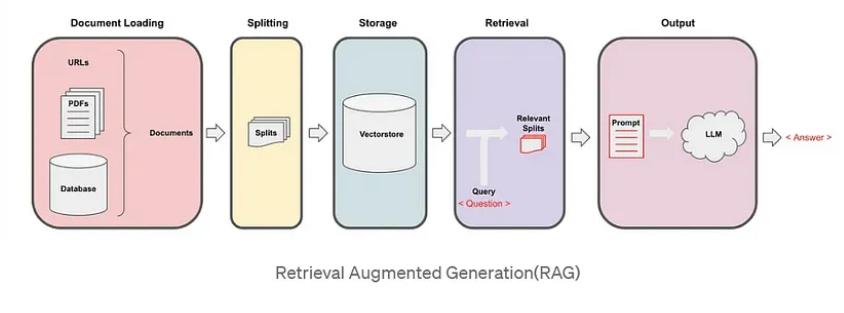

In [1]:
!pip install -U pypdf langchain_community chromadb langchain langchain_openai openai tiktoken rank_bm25 sentence_transformers cohere langchain_cohere flashrank faiss-cpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 643.9/643.9 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.6/340.6 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.2/259.2 kB 16.0 MB/s eta 0:0

In [2]:
from langchain_openai import OpenAIEmbeddings
from langchain_openai import OpenAI
import os
from google.colab import userdata
from langchain_text_splitters import RecursiveCharacterTextSplitter, CharacterTextSplitter
from langchain_community.document_loaders import TextLoader
from langchain.docstore.document import Document
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder
from langchain_cohere import CohereRerank
import cohere
from langchain.document_loaders import PyPDFLoader
from google.colab import drive
from langchain.vectorstores import Chroma
import chromadb
from langchain.retrievers.merger_retriever import MergerRetriever
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser
from langchain_openai import ChatOpenAI
from langchain.chains import RetrievalQA
import langchain
from langchain_community.vectorstores import FAISS

In [3]:
OPENAI_API_TOKEN=userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = OPENAI_API_TOKEN

In [36]:
import textwrap
def wrap_text(text, width=90): #preserve_newlines
    # Split the input text into lines based on newline characters
    lines = text.split('\n')

    # Wrap each line individually
    wrapped_lines = [textwrap.fill(line, width=width) for line in lines]

    # Join the wrapped lines back together using newline characters
    wrapped_text = '\n'.join(wrapped_lines)

    return wrapped_text

In [4]:
docs = [
    Document(
        page_content="A bunch of scientists bring back dinosaurs and mayhem breaks loose",
        metadata={"year": 1993, "rating": 7.7, "genre": "science fiction"},
    ),
    Document(
        page_content="Leo DiCaprio gets lost in a dream within a dream within a dream within a ...",
        metadata={"year": 2010, "director": "Christopher Nolan", "rating": 8.2},
    ),
    Document(
        page_content="A psychologist / detective gets lost in a series of dreams within dreams within dreams and Inception reused the idea",
        metadata={"year": 2006, "director": "Satoshi Kon", "rating": 8.6},
    ),
    Document(
        page_content="A bunch of normal-sized women are supremely wholesome and some men pine after them",
        metadata={"year": 2019, "director": "Greta Gerwig", "rating": 8.3},
    ),
    Document(
        page_content="Toys come alive and have a blast doing so",
        metadata={"year": 1995, "genre": "animated"},
    ),
    Document(
        page_content="A hacker discovers reality is a simulation and leads a rebellion against the machines controlling it.",
        metadata={"year": 1999, "director": "Lana Wachowski, Lilly Wachowski", "rating": 8.7, "genre": "science fiction"},
    ),
    Document(
        page_content="A young lion prince flees his kingdom only to learn the true meaning of responsibility and bravery.",
        metadata={"year": 1994, "rating": 8.5, "genre": "animated"},
    ),
    Document(
        page_content="Batman faces off against the Joker, a criminal mastermind who plunges Gotham into chaos.",
        metadata={"year": 2008, "director": "Christopher Nolan", "rating": 9.0, "genre": "action"},
    ),
    Document(
        page_content="A team of explorers travel through a wormhole in space in an attempt to ensure humanity's survival.",
        metadata={"year": 2014, "director": "Christopher Nolan", "rating": 8.6, "genre": "science fiction"},
    )
]

In [5]:
embeddings = OpenAIEmbeddings()
vectorstore = Chroma.from_documents(docs, embeddings)

In [7]:
question1 = "Which 1994 animated movie has a rating of 8.5?"
vectorstore.similarity_search(question1) # Not much relevant data

[Document(metadata={'genre': 'animated', 'year': 1995}, page_content='Toys come alive and have a blast doing so'),
 Document(metadata={'year': 1994, 'genre': 'animated', 'rating': 8.5}, page_content='A young lion prince flees his kingdom only to learn the true meaning of responsibility and bravery.'),
 Document(metadata={'year': 1993, 'genre': 'science fiction', 'rating': 7.7}, page_content='A bunch of scientists bring back dinosaurs and mayhem breaks loose'),
 Document(metadata={'director': 'Christopher Nolan', 'genre': 'science fiction', 'year': 2014, 'rating': 8.6}, page_content="A team of explorers travel through a wormhole in space in an attempt to ensure humanity's survival.")]

In [9]:
from langchain.chains.query_constructor.base import AttributeInfo
from langchain.retrievers.self_query.base import SelfQueryRetriever

In [10]:
metadata_field_info = [
    AttributeInfo(
        name="genre",
        description="The genre of the movie. One of ['science fiction', 'comedy', 'drama', 'thriller', 'romance', 'action', 'animated']",
        type="string",
    ),
    AttributeInfo(
        name="year",
        description="The year the movie was released",
        type="integer",
    ),
    AttributeInfo(
        name="director",
        description="The name of the movie director",
        type="string",
    ),
    AttributeInfo(
        name="rating", description="A 1-10 rating for the movie", type="float"
    ),
]

In [11]:
document_content_description = "Brief summary of a movie"

In [26]:
from langchain.chains.query_constructor.base import (
    StructuredQueryOutputParser,
    get_query_constructor_prompt,
)

prompt = get_query_constructor_prompt(
    document_content_description,
    metadata_field_info,
)
output_parser = StructuredQueryOutputParser.from_components()
query_constructor = prompt | llm | output_parser

ImportError: Cannot import lark, please install it with 'pip install lark'.

In [23]:
prompt

FewShotPromptTemplate(input_variables=['query'], input_types={}, partial_variables={}, examples=[{'i': 1, 'data_source': '```json\n{{\n    "content": "Lyrics of a song",\n    "attributes": {{\n        "artist": {{\n            "type": "string",\n            "description": "Name of the song artist"\n        }},\n        "length": {{\n            "type": "integer",\n            "description": "Length of the song in seconds"\n        }},\n        "genre": {{\n            "type": "string",\n            "description": "The song genre, one of "pop", "rock" or "rap""\n        }}\n    }}\n}}\n```', 'user_query': 'What are songs by Taylor Swift or Katy Perry about teenage romance under 3 minutes long in the dance pop genre', 'structured_request': '```json\n{{\n    "query": "teenager love",\n    "filter": "and(or(eq(\\"artist\\", \\"Taylor Swift\\"), eq(\\"artist\\", \\"Katy Perry\\")), lt(\\"length\\", 180), eq(\\"genre\\", \\"pop\\"))"\n}}\n```'}, {'i': 2, 'data_source': '```json\n{{\n    "con

In [31]:
llm = ChatOpenAI()

In [30]:
!pip install  --upgrade lark  --upgrade lark-parser
from langchain.chains.query_constructor.base import (
    StructuredQueryOutputParser,
    get_query_constructor_prompt,
)

prompt = get_query_constructor_prompt(
    document_content_description,
    metadata_field_info,
)
output_parser = StructuredQueryOutputParser.from_components()
query_constructor = prompt | llm | output_parser

ImportError: Cannot import lark, please install it with 'pip install lark'.

In [32]:
query_constructor.invoke(
    {
        "query": "What are some sci-fi movies from the 90's directed by Luc Besson about taxi drivers"
    }
)

NameError: name 'query_constructor' is not defined

In [33]:
from langchain.retrievers.self_query.chroma import ChromaTranslator

retriever = SelfQueryRetriever(
    query_constructor=query_constructor,
    vectorstore=vectorstore,
    structured_query_translator=ChromaTranslator(),
)

NameError: name 'query_constructor' is not defined

In [ ]:
retriever.invoke(
    "What's a movie after 1990 but before 2005 that's all about toys, and preferably is animated"
)

In [34]:
template = """Answer the question based only on the following context:
{context}

Question: {question}
"""

In [35]:
chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

text_reply = chain.invoke("Tell me about the movie which have rating more than 7.")

print(wrap_text(text_reply))

NameError: name 'retriever' is not defined

In [ ]:
text_reply = chain.invoke("Tell me about the movie which have rating more than 7.")

print(wrap_text(text_reply))